## Econ 196 Seminar: Quantitative Long-Run Global Economic History

# PRE-CLASS ASSIGNMENT: Due 2026-02-22 23:59 PST (Su)



---
---

# The Femur Is the Longest & Largest Bone in the Human Body

* **Jongman, Willem M., Jan P.A.M. Jacobs, & Geertje M. Klein Goldewijk**. 2019. “Health and Wealth in the Roman Empire.” _Economics & Human Biology_ 34 (August), pp. 138–150. <<https://doi.org/10.1016/j.ehb.2019.01.005>>.

They have not finished writing papers based on their assembly of every archeological bone measurement that they could find, but they were gracious enough to give me the femur lengths, for which I thank them and am very grateful

---

##### NOTE: A 10-mm femur-length difference is roughly an inch in adult height...

* For males: Height = 2.32 × Femur Length + 655.3
* For females: Height = 2.47 × Femur Length + 541.0

* For males: a 400 mm femur = 5'2.3"
* For females: a 400 mm femur = 5'0.2"
* For males: a 450 mm femur = 5'6.9"
* For females: a 450 mm femur = 5'5.1"
* For males: a 500 mm femur = 5'11.5"
* For females: a 500 mm femur = 5'9.9"


### Provinces of the Roman Empire Around the Year 200

![The Roman Empire Around the Year 200 Map](2024-09-13-econ-135/roman_empire_200.png)

In [1]:
# getting information about mapping between province names and province numerical identifier into the system

provinces = [
    "Achaea", "Aegyptus", "Africa", "Alpes Cottiae", "Alpes Maritimae", "Alpes Poeninae",
    "Arabia Petrae", "Armenia", "Asia", "Assyria", "Bithynia et Pontus", "Britannia",
    "Cappadocia", "Cilicia", "Corsica et Sardinia", "Creta et Cyrenaica", "Cyprus", "Dacia",
    "Dalmatia", "Epirus", "Galatia", "Gallia Aquitania", "Gallia Belgica", "Gallia Lugdunensis",
    "Gallia Narbonensis", "Germania Inferior", "Germania Superior", "Hispania Baetica",
    "Hispania Tarraconensis", "Italia", "Iudaea", "Lusitania", "Lycia et Pamphylia", "Macedonia",
    "Mauretania Caesariensis", "Mauretania Tingitana", "Mesopotamia", "Moesia Inferior",
    "Moesia Superior", "Noricum", "Pannonia Inferior", "Pannonia Superior", "Raetia", "Sicilia",
    "Syria", "Taurica", "Thracia"
]

numbered_provinces = {i+1: province for i, province in enumerate(provinces)}


import pandas as pd

# Create a DataFrame from the numbered provinces
numbered_provinces_df = pd.DataFrame(list(numbered_provinces.items()), columns=["Number", "Province"])

In [2]:
# import our bone lengths

import pandas as pd

df = pd.read_csv('2024-09-13-econ-135/roman_femurs.csv')

In [3]:
# get our province names into a dataframe

df['ProvinceName'] = df['Province'].map(numbered_provinces)

In [4]:
# make a dataframe with just the British bone observations

df_britannia = df[df['ProvinceName'] == 'Britannia']

In [5]:
# we don't need the name "Britain" anymore

df_britannia = df_britannia.drop(columns=['ProvinceName'])

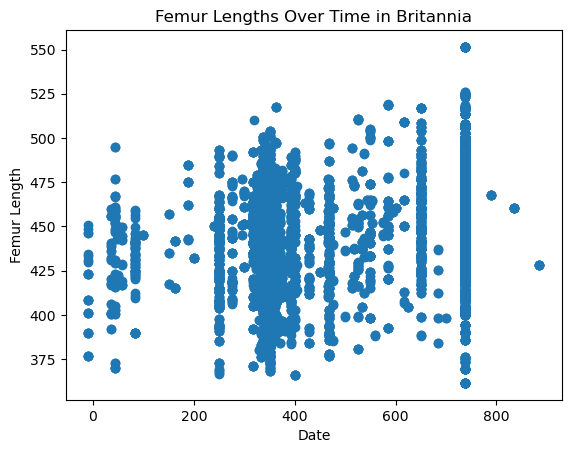

In [6]:
# now we begin looking at the data

import matplotlib.pyplot as plt

plt.scatter(df_britannia['Date'], df_britannia['Femur'])

# Add labels and title
plt.xlabel('Date')
plt.ylabel('Femur Length')
plt.title('Femur Lengths Over Time in Britannia')

# Display the plot
plt.show()

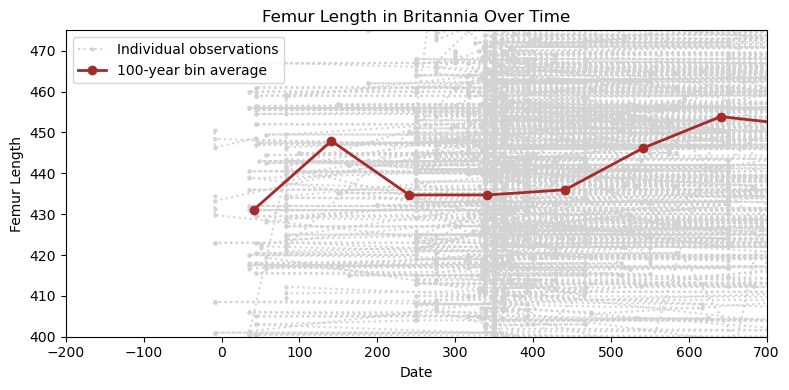

In [7]:
# let's look at averages, focusing in on the Roman imperial
# period of -200 to 700
#
# before -200 Ro,an rule does not extend beyond Sicily, 
# Sardinia, and Italy south of the Po River
#
# fall of the Roman Empire in the west: 400 to 470
#
# major Arab conquests: 630 to 650; after that the "Roman
# Empire" is essentially Turkey plus pieces of the Balkans

import pandas as pd
import matplotlib.pyplot as plt

# 1. Create 100‑year bins and grouped series for Britannia
bins = range(df_britannia['Date'].min(),
             df_britannia['Date'].max() + 100,
             100)

df_brit = df_britannia.copy()  # avoid SettingWithCopyWarning
df_brit['Date_bin'] = pd.cut(df_brit['Date'], bins)

grouped_brit = (
    df_brit
    .groupby('Date_bin', observed=False)['Femur']
    .mean()
    .reset_index()
)

# 2. Midpoints of each bin for the x‑axis
brit_bin_midpoints = grouped_brit['Date_bin'].apply(lambda x: x.mid)

# 3. Plot raw points + 100‑year bin averages on the same axes
plt.figure(figsize=(8, 4))

# Raw data
plt.plot(df_brit['Date'],
         df_brit['Femur'],
         color='lightgray',
         linestyle=':',
         marker='o',
         markersize=2,
         label='Individual observations')

# Binned averages
plt.plot(brit_bin_midpoints,
         grouped_brit['Femur'],
         color='brown',
         linewidth=2,
         marker='o',
         label='100‑year bin average')

plt.xlabel('Date')
plt.xlim(-200,700)          # focus in on Roman Imperium
plt.ylabel('Femur Length')
plt.ylim(400, 475)
plt.title('Femur Length in Britannia Over Time')
plt.legend()
plt.tight_layout()
plt.show()


In [9]:
df_WesternMediterranean = df[df['WesternMediterranean'] == 1]
df_GreekEast = df[df['GreekEast'] == 1]
df_NorthWestEurope = df[df['NorthWestEurope'] == 1]
df_SouthEastEurope = df[df['SouthEastEurope'] == 1]

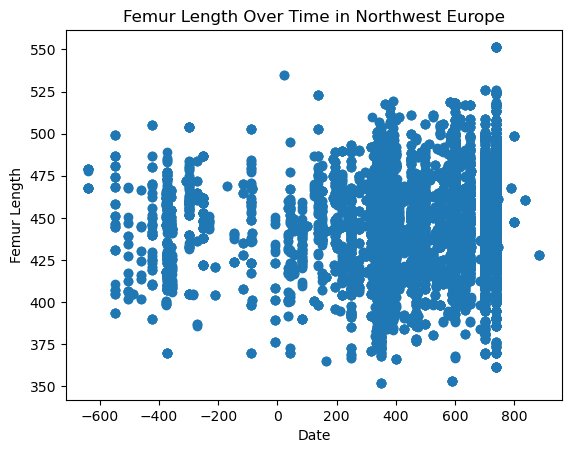

In [10]:
# the bone data for northwest Europe

import matplotlib.pyplot as plt

plt.scatter(df_NorthWestEurope['Date'], df_NorthWestEurope['Femur'])

# Add labels and title
plt.xlabel('Date')
plt.ylabel('Femur Length')
plt.title('Femur Length Over Time in Northwest Europe')

# Display the plot
plt.show()

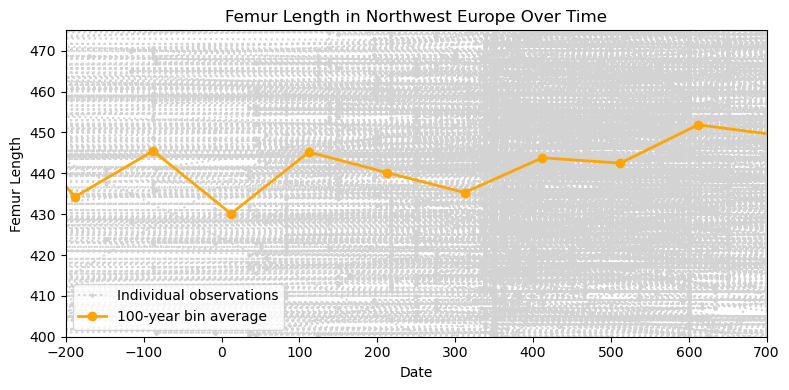

In [11]:
# average femur length, focusing in on the Roman imperial period

import pandas as pd
import matplotlib.pyplot as plt

# 1. Create 100‑year bins and grouped series for Northwest Europe
bins = range(df_NorthWestEurope['Date'].min(),
             df_NorthWestEurope['Date'].max() + 100,
             100)

df_nwe = df_NorthWestEurope.copy()  # avoid SettingWithCopyWarning
df_nwe['Date_bin'] = pd.cut(df_nwe['Date'], bins)

grouped_nwe = (
    df_nwe
    .groupby('Date_bin', observed=False)['Femur']
    .mean()
    .reset_index()
)

# 2. Midpoints of each bin for the x‑axis
nwe_bin_midpoints = grouped_nwe['Date_bin'].apply(lambda x: x.mid)

# 3. Plot raw points + 100‑year bin averages on the same axes
plt.figure(figsize=(8, 4))

# Raw data
plt.plot(df_nwe['Date'],
         df_nwe['Femur'],
         color='lightgray',
         linestyle=':',
         marker='o',
         markersize=2,
         label='Individual observations')

# Binned averages
plt.plot(nwe_bin_midpoints,
         grouped_nwe['Femur'],
         color='orange',
         linewidth=2,
         marker='o',
         label='100‑year bin average')

plt.xlabel('Date')
plt.xlim(-200,700)          # focus in on Roman Imperium
plt.ylabel('Femur Length')
plt.ylim(400, 475)
plt.title('Femur Length in Northwest Europe Over Time')
plt.legend()
plt.tight_layout()
plt.show()


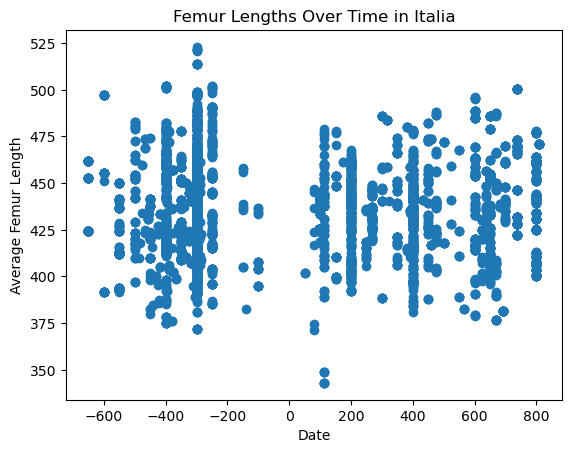

In [12]:
# how about the heart of the early empire—the place to which
# all the tribute was flowing?

df_italia = df[df['ProvinceName'] == 'Italia']

import matplotlib.pyplot as plt

plt.scatter(df_italia['Date'], df_italia['Femur'])

# Add labels and title
plt.xlabel('Date')
plt.ylabel('Average Femur Length')
plt.title('Femur Lengths Over Time in Italia')

# Display the plot
plt.show()

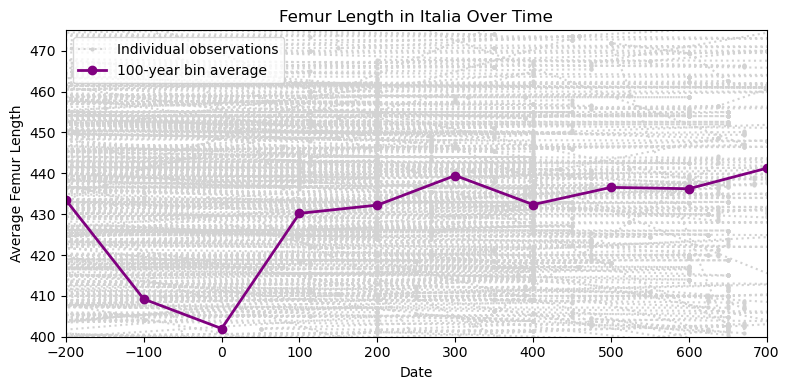

In [13]:
# and the average time-series pattern

import pandas as pd
import matplotlib.pyplot as plt

# 1. Create the 100‑year bins and grouped series for Italia
bins = range(df_italia['Date'].min(),
             df_italia['Date'].max() + 100,
             100)

df_italia = df_italia.copy()  # avoid SettingWithCopyWarning
df_italia['Date_bin'] = pd.cut(df_italia['Date'], bins)

grouped_italia = (
    df_italia
    .groupby('Date_bin', observed=False)['Femur']
    .mean()
    .reset_index()
)

# 2. Midpoints of each bin for the x‑axis
italia_bin_midpoints = grouped_italia['Date_bin'].apply(lambda x: x.mid)

# 3. Plot raw points + 100‑year bin averages on the same axes
plt.figure(figsize=(8, 4))

# Raw data
plt.plot(df_italia['Date'],
         df_italia['Femur'],
         color='lightgray',
         linestyle=':',
         marker='o',
         markersize=2,
         label='Individual observations')

# Binned averages
plt.plot(italia_bin_midpoints,
         grouped_italia['Femur'],
         color='purple',
         linewidth=2,
         marker='o',
         label='100‑year bin average')

plt.xlabel('Date')
plt.xlim(-200,700)          # focus in on Roman Imperium
plt.ylabel('Average Femur Length')
plt.ylim(400, 475)
plt.title('Femur Length in Italia Over Time')
plt.legend()
plt.tight_layout()
plt.show()


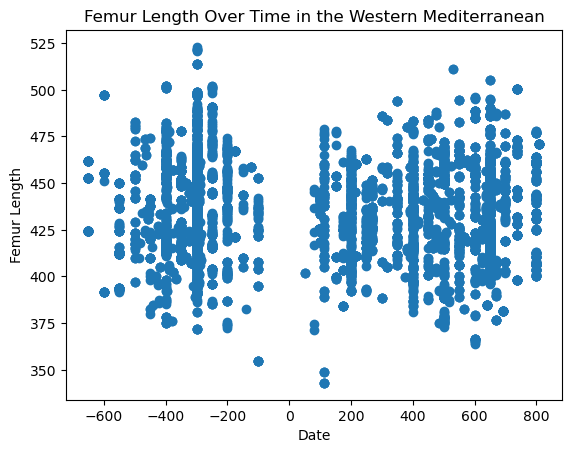

In [14]:
# and the bone data for the Western Mediterranean provinces

import matplotlib.pyplot as plt

plt.scatter(df_WesternMediterranean['Date'], df_WesternMediterranean['Femur'])

# Add labels and title
plt.xlabel('Date')
plt.ylabel('Femur Length')
plt.title('Femur Length Over Time in the Western Mediterranean')

# Display the plot
plt.show()

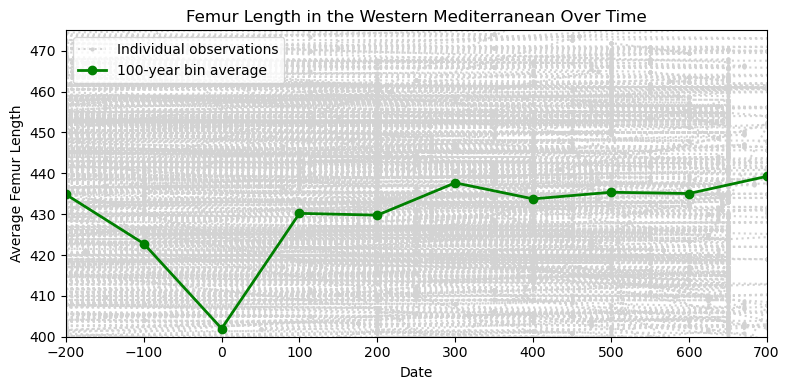

In [15]:
# and the time series

import pandas as pd
import matplotlib.pyplot as plt

# 1. Create the 100‑year bins and grouped series for the Western Mediterranean
bins = range(df_WesternMediterranean['Date'].min(),
             df_WesternMediterranean['Date'].max() + 100,
             100)

df_WesternMediterranean = df_WesternMediterranean.copy()  # avoid SettingWithCopyWarning
df_WesternMediterranean['Date_bin'] = pd.cut(df_WesternMediterranean['Date'], bins)

grouped_west = (
    df_WesternMediterranean
    .groupby('Date_bin', observed=False)['Femur']
    .mean()
    .reset_index()
)

# 2. Midpoints of each bin for the x‑axis
west_bin_midpoints = grouped_west['Date_bin'].apply(lambda x: x.mid)

# 3. Plot raw points + 100‑year bin averages on the same axes
plt.figure(figsize=(8, 4))

# Raw data
plt.plot(df_WesternMediterranean['Date'],
         df_WesternMediterranean['Femur'],
         color='lightgray',
         linestyle=':',
         marker='o',
         markersize=2,
         label='Individual observations')

# Binned averages
plt.plot(west_bin_midpoints,
         grouped_west['Femur'],
         color='green',
         linewidth=2,
         marker='o',
         label='100‑year bin average')

plt.xlabel('Date')
plt.xlim(-200,700)          # focus in on Roman Imperium
plt.ylabel('Average Femur Length')
plt.ylim(400, 475)
plt.title('Femur Length in the Western Mediterranean Over Time')
plt.legend()
plt.tight_layout()
plt.show()


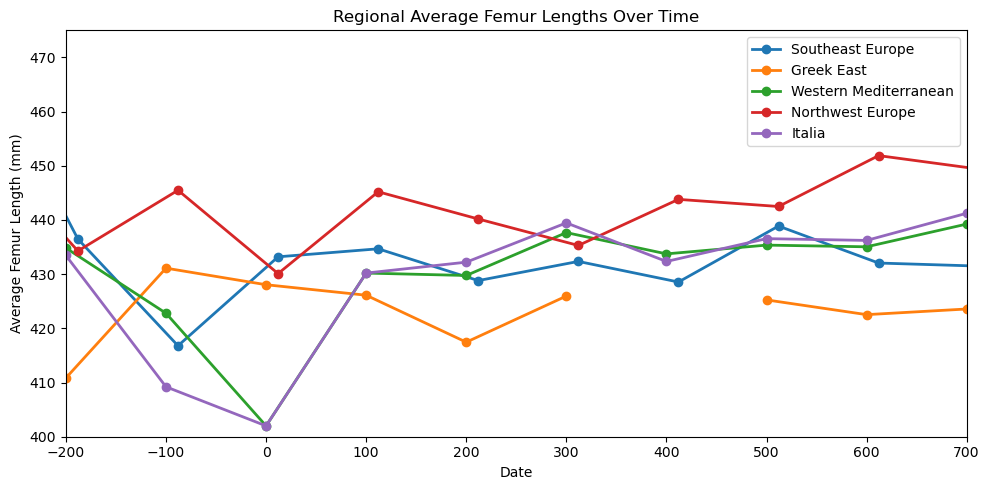

In [16]:
# for the five segments of the empire—northwest Europe,
# western Mediterranean, southeast Europe, Greek east,
# and Italy

import pandas as pd
import matplotlib.pyplot as plt

# Collect your regional DataFrames in a dict
regions = {
    "Southeast Europe": df_SouthEastEurope,
    "Greek East": df_GreekEast,
    "Western Mediterranean": df_WesternMediterranean,
    "Northwest Europe": df_NorthWestEurope,
    "Italia": df_italia,
}

plt.figure(figsize=(10, 5))

for label, subdf in regions.items():
    # Drop NA Dates/Femurs just in case
    sub = subdf[['Date', 'Femur']].dropna()

    # Region‑specific 100‑year bins
    bins = range(sub['Date'].min(),
                 sub['Date'].max() + 100,
                 100)

    # Work on a copy to avoid SettingWithCopyWarning
    sub = sub.copy()
    sub['Date_bin'] = pd.cut(sub['Date'], bins)

    grouped = (
        sub
        .groupby('Date_bin', observed=False)['Femur']
        .mean()
        .reset_index()
    )

    # Bin midpoints for x‑axis
    x_mid = grouped['Date_bin'].apply(lambda x: x.mid)
    y_mean = grouped['Femur']

    # Plot just the average line for this region
    plt.plot(x_mid, y_mean, marker='o', linewidth=2, label=label)

plt.xlabel('Date')
plt.ylabel('Average Femur Length (mm)')
plt.ylim(400, 475)          # keep the zoomed scale
plt.xlim(-200,700)          # focus in on Roman Imperium
plt.title('Regional Average Femur Lengths Over Time')
plt.legend()
plt.tight_layout()
plt.show()


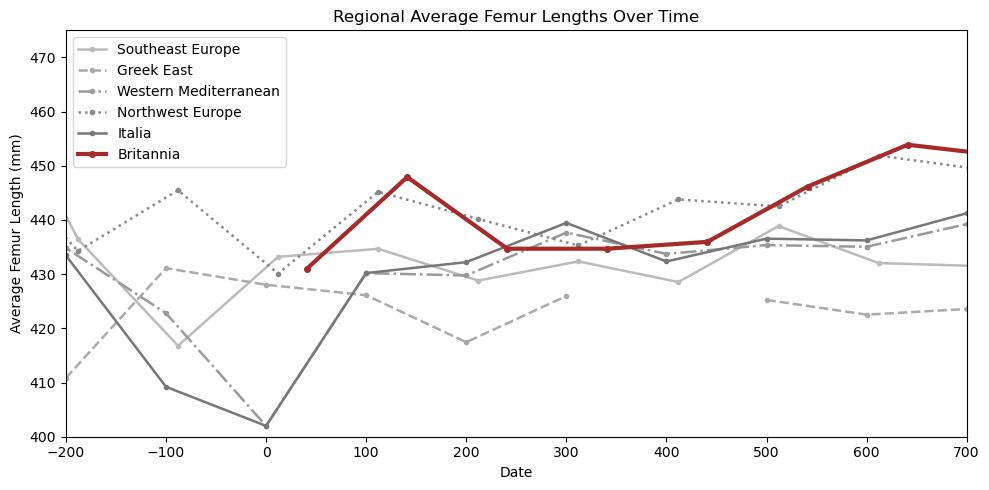

In [17]:
# adding in Britain

import pandas as pd
import matplotlib.pyplot as plt

regions = {
    "Southeast Europe": df_SouthEastEurope,
    "Greek East": df_GreekEast,
    "Western Mediterranean": df_WesternMediterranean,
    "Northwest Europe": df_NorthWestEurope,
    "Italia": df_italia,
    "Britannia": df_britannia,
}

# Grey styles for non‑Britannia series
grey_styles = [
    ("#bbbbbb", "-"),    # light gray, solid
    ("#aaaaaa", "--"),   # light gray, dashed
    ("#999999", "-."),   # darker, dash‑dot
    ("#888888", ":"),    # dotted
    ("#777777", "-"),    # darker solid
]

plt.figure(figsize=(10, 5))

grey_idx = 0

for label, subdf in regions.items():
    sub = subdf[["Date", "Femur"]].dropna().copy()

    bins = range(sub["Date"].min(), sub["Date"].max() + 100, 100)
    sub["Date_bin"] = pd.cut(sub["Date"], bins)

    grouped = (
        sub
        .groupby("Date_bin", observed=False)["Femur"]
        .mean()
        .reset_index()
    )

    x_mid = grouped["Date_bin"].apply(lambda x: x.mid)
    y_mean = grouped["Femur"]

    if label == "Britannia":
        # Make Britannia pop: strong color, thicker line
        plt.plot(
            x_mid,
            y_mean,
            color="brown",
            linewidth=3,
            marker="o",
            markersize=4,
            label=label,
        )
    else:
        color, linestyle = grey_styles[grey_idx % len(grey_styles)]
        grey_idx += 1
        plt.plot(
            x_mid,
            y_mean,
            color=color,
            linestyle=linestyle,
            linewidth=1.8,
            marker="o",
            markersize=3,
            label=label,
        )

plt.xlabel("Date")
plt.ylabel("Average Femur Length (mm)")
plt.ylim(400, 475)
plt.xlim(-200, 700)
plt.title("Regional Average Femur Lengths Over Time")
plt.legend()
plt.tight_layout()
plt.show()


In [ ]:
# the bone data for northwest Europe

import matplotlib.pyplot as plt

plt.scatter(df_NorthWestEurope['Date'], df_NorthWestEurope['Femur'])

# Add labels and title
plt.xlabel('Date')
plt.ylabel('Femur Length')
plt.title('Femur Length Over Time in Northwest Europe')

# Display the plot
plt.show()

In [ ]:
# average femur length, focusing in on the Roman imperial period

import pandas as pd
import matplotlib.pyplot as plt

# 1. Create 100‑year bins and grouped series for Northwest Europe
bins = range(df_NorthWestEurope['Date'].min(),
             df_NorthWestEurope['Date'].max() + 100,
             100)

df_nwe = df_NorthWestEurope.copy()  # avoid SettingWithCopyWarning
df_nwe['Date_bin'] = pd.cut(df_nwe['Date'], bins)

grouped_nwe = (
    df_nwe
    .groupby('Date_bin', observed=False)['Femur']
    .mean()
    .reset_index()
)

# 2. Midpoints of each bin for the x‑axis
nwe_bin_midpoints = grouped_nwe['Date_bin'].apply(lambda x: x.mid)

# 3. Plot raw points + 100‑year bin averages on the same axes
plt.figure(figsize=(8, 4))

# Raw data
plt.plot(df_nwe['Date'],
         df_nwe['Femur'],
         color='lightgray',
         linestyle=':',
         marker='o',
         markersize=2,
         label='Individual observations')

# Binned averages
plt.plot(nwe_bin_midpoints,
         grouped_nwe['Femur'],
         color='orange',
         linewidth=2,
         marker='o',
         label='100‑year bin average')

plt.xlabel('Date')
plt.xlim(-200,700)          # focus in on Roman Imperium
plt.ylabel('Femur Length')
plt.ylim(400, 475)
plt.title('Femur Length in Northwest Europe Over Time')
plt.legend()
plt.tight_layout()
plt.show()


In [ ]:
# how about the heart of the early empire—the place to which
# all the tribute was flowing?

df_italia = df[df['ProvinceName'] == 'Italia']

import matplotlib.pyplot as plt

plt.scatter(df_italia['Date'], df_italia['Femur'])

# Add labels and title
plt.xlabel('Date')
plt.ylabel('Average Femur Length')
plt.title('Femur Lengths Over Time in Italia')

# Display the plot
plt.show()

In [ ]:
# and the average time-series pattern

import pandas as pd
import matplotlib.pyplot as plt

# 1. Create the 100‑year bins and grouped series for Italia
bins = range(df_italia['Date'].min(),
             df_italia['Date'].max() + 100,
             100)

df_italia = df_italia.copy()  # avoid SettingWithCopyWarning
df_italia['Date_bin'] = pd.cut(df_italia['Date'], bins)

grouped_italia = (
    df_italia
    .groupby('Date_bin', observed=False)['Femur']
    .mean()
    .reset_index()
)

# 2. Midpoints of each bin for the x‑axis
italia_bin_midpoints = grouped_italia['Date_bin'].apply(lambda x: x.mid)

# 3. Plot raw points + 100‑year bin averages on the same axes
plt.figure(figsize=(8, 4))

# Raw data
plt.plot(df_italia['Date'],
         df_italia['Femur'],
         color='lightgray',
         linestyle=':',
         marker='o',
         markersize=2,
         label='Individual observations')

# Binned averages
plt.plot(italia_bin_midpoints,
         grouped_italia['Femur'],
         color='purple',
         linewidth=2,
         marker='o',
         label='100‑year bin average')

plt.xlabel('Date')
plt.xlim(-200,700)          # focus in on Roman Imperium
plt.ylabel('Average Femur Length')
plt.ylim(400, 475)
plt.title('Femur Length in Italia Over Time')
plt.legend()
plt.tight_layout()
plt.show()


In [ ]:
# and the bone data for the Western Mediterranean provinces

import matplotlib.pyplot as plt

plt.scatter(df_WesternMediterranean['Date'], df_WesternMediterranean['Femur'])

# Add labels and title
plt.xlabel('Date')
plt.ylabel('Femur Length')
plt.title('Femur Length Over Time in the Western Mediterranean')

# Display the plot
plt.show()

In [ ]:
# and the time series

import pandas as pd
import matplotlib.pyplot as plt

# 1. Create the 100‑year bins and grouped series for the Western Mediterranean
bins = range(df_WesternMediterranean['Date'].min(),
             df_WesternMediterranean['Date'].max() + 100,
             100)

df_WesternMediterranean = df_WesternMediterranean.copy()  # avoid SettingWithCopyWarning
df_WesternMediterranean['Date_bin'] = pd.cut(df_WesternMediterranean['Date'], bins)

grouped_west = (
    df_WesternMediterranean
    .groupby('Date_bin', observed=False)['Femur']
    .mean()
    .reset_index()
)

# 2. Midpoints of each bin for the x‑axis
west_bin_midpoints = grouped_west['Date_bin'].apply(lambda x: x.mid)

# 3. Plot raw points + 100‑year bin averages on the same axes
plt.figure(figsize=(8, 4))

# Raw data
plt.plot(df_WesternMediterranean['Date'],
         df_WesternMediterranean['Femur'],
         color='lightgray',
         linestyle=':',
         marker='o',
         markersize=2,
         label='Individual observations')

# Binned averages
plt.plot(west_bin_midpoints,
         grouped_west['Femur'],
         color='green',
         linewidth=2,
         marker='o',
         label='100‑year bin average')

plt.xlabel('Date')
plt.xlim(-200,700)          # focus in on Roman Imperium
plt.ylabel('Average Femur Length')
plt.ylim(400, 475)
plt.title('Femur Length in the Western Mediterranean Over Time')
plt.legend()
plt.tight_layout()
plt.show()


In [ ]:
# for the five segments of the empire—northwest Europe,
# western Mediterranean, southeast Europe, Greek east,
# and Italy

import pandas as pd
import matplotlib.pyplot as plt

# Collect your regional DataFrames in a dict
regions = {
    "Southeast Europe": df_SouthEastEurope,
    "Greek East": df_GreekEast,
    "Western Mediterranean": df_WesternMediterranean,
    "Northwest Europe": df_NorthWestEurope,
    "Italia": df_italia,
}

plt.figure(figsize=(10, 5))

for label, subdf in regions.items():
    # Drop NA Dates/Femurs just in case
    sub = subdf[['Date', 'Femur']].dropna()

    # Region‑specific 100‑year bins
    bins = range(sub['Date'].min(),
                 sub['Date'].max() + 100,
                 100)

    # Work on a copy to avoid SettingWithCopyWarning
    sub = sub.copy()
    sub['Date_bin'] = pd.cut(sub['Date'], bins)

    grouped = (
        sub
        .groupby('Date_bin', observed=False)['Femur']
        .mean()
        .reset_index()
    )

    # Bin midpoints for x‑axis
    x_mid = grouped['Date_bin'].apply(lambda x: x.mid)
    y_mean = grouped['Femur']

    # Plot just the average line for this region
    plt.plot(x_mid, y_mean, marker='o', linewidth=2, label=label)

plt.xlabel('Date')
plt.ylabel('Average Femur Length (mm)')
plt.ylim(400, 475)          # keep the zoomed scale
plt.xlim(-200,700)          # focus in on Roman Imperium
plt.title('Regional Average Femur Lengths Over Time')
plt.legend()
plt.tight_layout()
plt.show()


In [ ]:
# adding in Britain

import pandas as pd
import matplotlib.pyplot as plt

regions = {
    "Southeast Europe": df_SouthEastEurope,
    "Greek East": df_GreekEast,
    "Western Mediterranean": df_WesternMediterranean,
    "Northwest Europe": df_NorthWestEurope,
    "Italia": df_italia,
    "Britannia": df_britannia,
}

# Grey styles for non‑Britannia series
grey_styles = [
    ("#bbbbbb", "-"),    # light gray, solid
    ("#aaaaaa", "--"),   # light gray, dashed
    ("#999999", "-."),   # darker, dash‑dot
    ("#888888", ":"),    # dotted
    ("#777777", "-"),    # darker solid
]

plt.figure(figsize=(10, 5))

grey_idx = 0

for label, subdf in regions.items():
    sub = subdf[["Date", "Femur"]].dropna().copy()

    bins = range(sub["Date"].min(), sub["Date"].max() + 100, 100)
    sub["Date_bin"] = pd.cut(sub["Date"], bins)

    grouped = (
        sub
        .groupby("Date_bin", observed=False)["Femur"]
        .mean()
        .reset_index()
    )

    x_mid = grouped["Date_bin"].apply(lambda x: x.mid)
    y_mean = grouped["Femur"]

    if label == "Britannia":
        # Make Britannia pop: strong color, thicker line
        plt.plot(
            x_mid,
            y_mean,
            color="brown",
            linewidth=3,
            marker="o",
            markersize=4,
            label=label,
        )
    else:
        color, linestyle = grey_styles[grey_idx % len(grey_styles)]
        grey_idx += 1
        plt.plot(
            x_mid,
            y_mean,
            color=color,
            linestyle=linestyle,
            linewidth=1.8,
            marker="o",
            markersize=3,
            label=label,
        )

plt.xlabel("Date")
plt.ylabel("Average Femur Length (mm)")
plt.ylim(400, 475)
plt.xlim(-200, 700)
plt.title("Regional Average Femur Lengths Over Time")
plt.legend()
plt.tight_layout()
plt.show()


## Indicators of "Civilization"

<img src="images/2026-02-17-dated-shipwrecks.png" />

<img src="images/2026-02-17-lead-pollution.png" />

<img src="images/2026-02-17-animal-bones.png" />

A lot of middle-class conveniences in the commodity production-and-trade mix...
